# Direct-CP benchmark with efficiency and background

This keeps the full paper-inspired $B^\pm\to K^\pm\pi^+\pi^-$ amplitude model while using the high-level CP toy and fit helpers. Toy generation uses the default inverse-transform sampler.


In [1]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from jaxpwa import (
    BaBarFlatte, CPBackgroundSpec, CPFitSession, CPRealImag, CPToyBackground,
    DecayChannel, DecayModel, LASS, NonResonant, Parameter, Resonance,
    enable_x64, generate_cp_toy, plot_dalitz,
)
from jaxpwa.background import FunctionalBackground
from jaxpwa.efficiency import FunctionalEfficiency
enable_x64()


In [2]:
truth_spec={
    "Kstar892":(1.00,0.00,+0.04,-0.03),
    "KpiS":(1.40,-0.60,-0.10,+0.08),
    "rho770":(0.65,0.10,+0.06,+0.04),
    "f0_980":(-0.20,1.00,-0.05,+0.07),
    "NR":(-0.50,0.10,0.00,0.00),
}
truth={}
shared={}
for name,(x,y,dx,dy) in truth_spec.items():
    pars=(
        Parameter.coefficient(f"{name}.x",x,owner=name,fixed=(name=="Kstar892"),step=0.01),
        Parameter.coefficient(f"{name}.y",y,owner=name,fixed=(name=="Kstar892"),step=0.01),
        Parameter.coefficient(f"{name}.dx",dx,owner=name,fixed=(name=="NR"),step=0.01),
        Parameter.coefficient(f"{name}.dy",dy,owner=name,fixed=(name=="NR"),step=0.01),
    )
    shared[name]=CPRealImag(*pars)
    truth.update({p.name:p.value for p in pars})

def components(q):
    c={name:coeff.for_charge(q) for name,coeff in shared.items()}
    return [
        Resonance("Kstar892",(0,2),c["Kstar892"],mass=0.8958,width=0.0474,spin=1,resonance_radius=4.0,parent_radius=4.0),
        Resonance("KpiS",(0,2),c["KpiS"],lineshape=LASS(2.07,3.32,1.8),mass=1.425,width=0.270,spin=0,resonance_radius=4.0,parent_radius=4.0),
        Resonance("rho770",(1,2),c["rho770"],mass=0.7753,width=0.1491,spin=1,resonance_radius=4.0,parent_radius=4.0),
        Resonance("f0_980",(1,2),c["f0_980"],lineshape=BaBarFlatte(),mass=0.965,width=0.0,spin=0,resonance_radius=4.0,parent_radius=4.0),
        NonResonant(c["NR"]),
    ]

plus_model=DecayModel(DecayChannel("B+",("K+","pi+","pi-")),components(+1))
minus_model=DecayModel(DecayChannel("B-",("K-","pi-","pi+")),components(-1))

eff=FunctionalEfficiency(lambda d:0.55+0.25*jnp.clip(d["s13"]/20.0,0,1))
bkg=FunctionalBackground(lambda d:0.4+0.6*jnp.clip(d["s23"]/25.0,0,1))


B+ / B-: 22470 22530


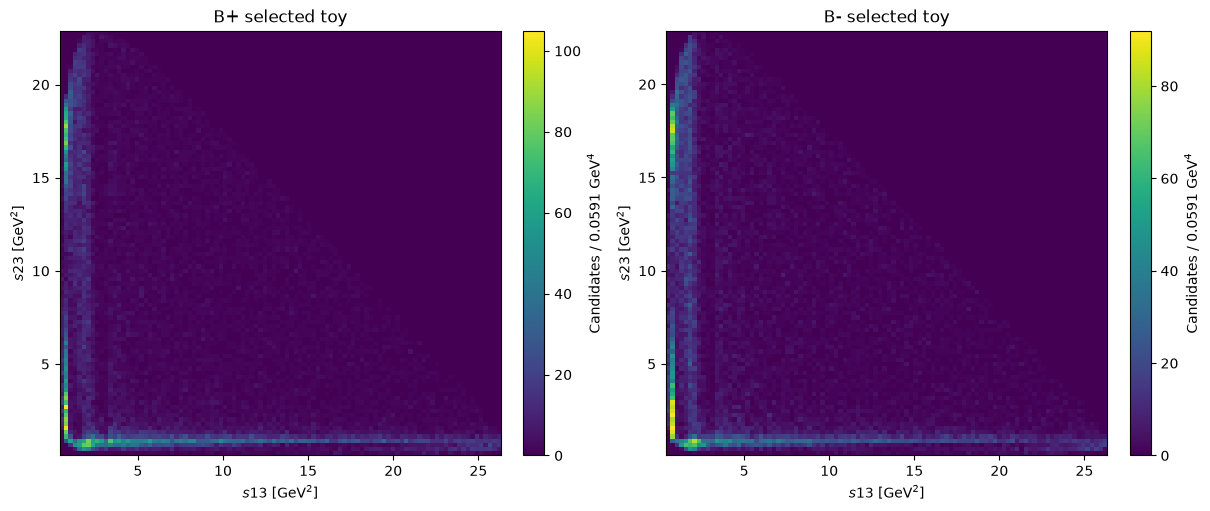

In [3]:
plus_data,minus_data=generate_cp_toy(
    plus_model,minus_model,45_000,parameters=truth,
    plus_efficiency=eff,minus_efficiency=eff,
    signal_fraction=0.82,backgrounds=(CPToyBackground("comb",bkg),),
    seed=606,
)
print("B+ / B-:",plus_data.size,minus_data.size)
fig,axes=plt.subplots(1,2,figsize=(12,5),constrained_layout=True)
plot_dalitz(plus_data,x="s13",y="s23",ax=axes[0],title="B+ selected toy")
plot_dalitz(minus_data,x="s13",y="s23",ax=axes[1],title="B- selected toy")
plt.show()


valid=True  NLL=250733.880630
parameter                           value            error
Kstar892.x                              1                0
Kstar892.y                              0                0
Kstar892.dx                     0.0319984        0.0070959
Kstar892.dy                    -0.0625686        0.0553131
KpiS.x                            1.41022        0.0199309
KpiS.y                          -0.560634        0.0299011
KpiS.dx                        -0.0944783        0.0222302
KpiS.dy                         0.0505819        0.0640677
rho770.x                         0.645646        0.0107413
rho770.y                         0.105748        0.0261823
rho770.dx                       0.0476898       0.00787993
rho770.dy                       0.0590892        0.0223838
f0_980.x                        -0.213212        0.0378125
f0_980.y                          1.00372        0.0152438
f0_980.dx                      -0.0752487        0.0350189
f0_980.dy                 

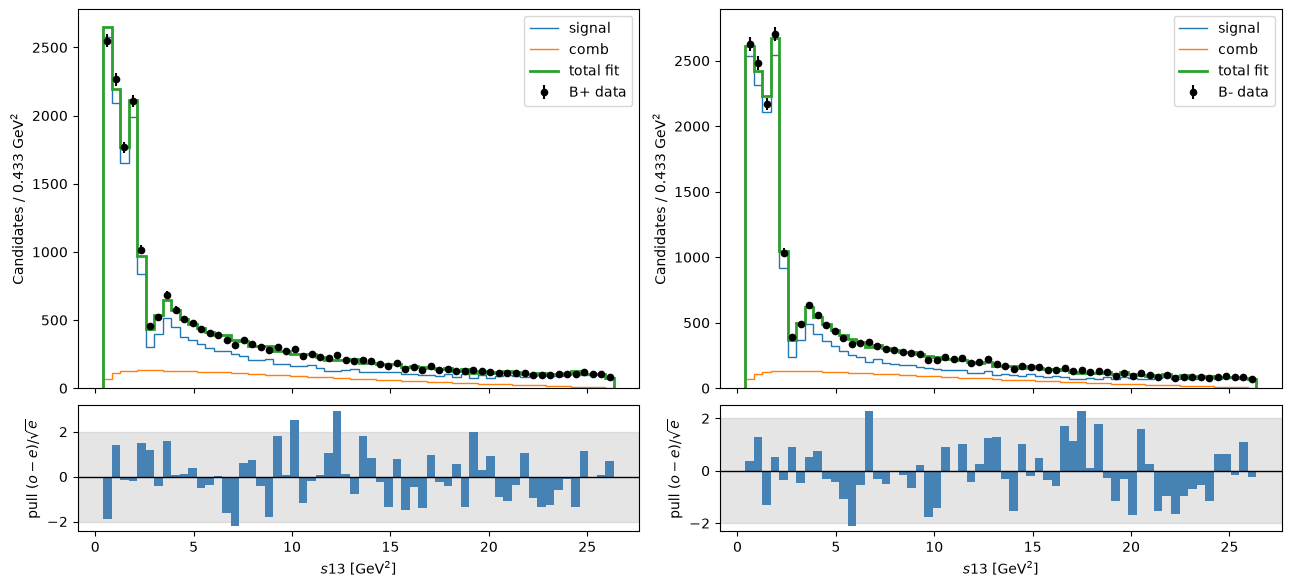

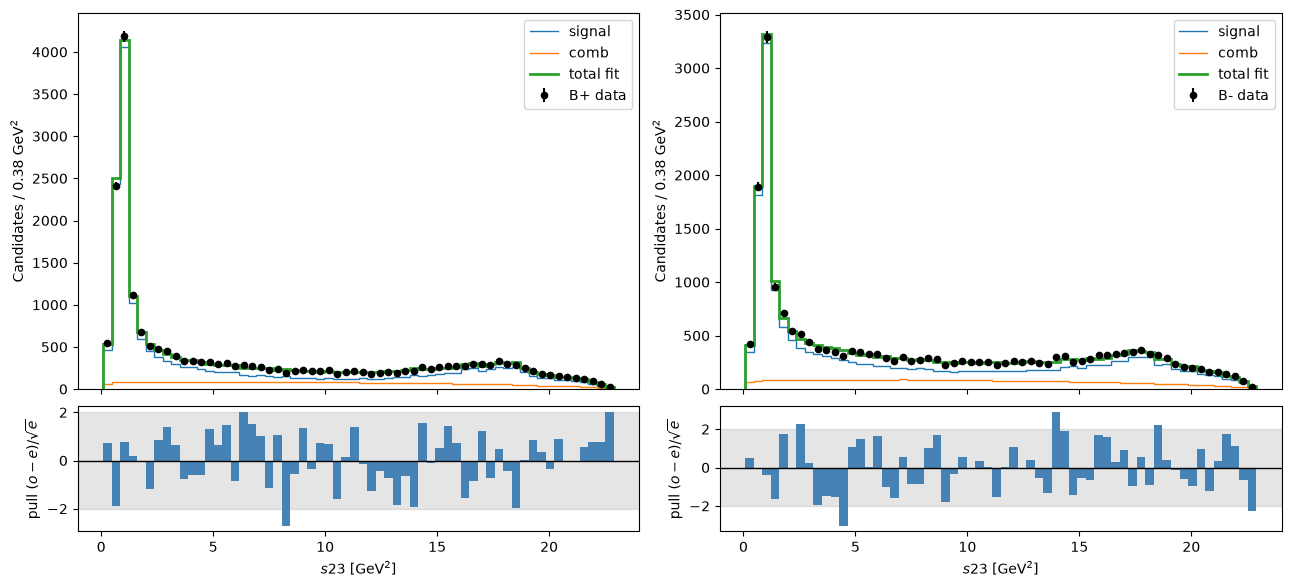

In [5]:
f_sig=Parameter("signal_fraction",0.74,bounds=(0.05,0.99),step=0.01)
session=CPFitSession(
    plus_model,minus_model,plus_data,minus_data,
    plus_efficiency=eff,minus_efficiency=eff,
    signal_fraction=f_sig,backgrounds=(CPBackgroundSpec("comb",bkg),),
)
rng=np.random.default_rng(6061)
start={p.name:truth[p.name]+rng.normal(0,0.05) for p in session.parameters if not p.fixed and p.name!="signal_fraction"}
start["signal_fraction"]=0.74
result=session.fit(start,simplex=True,ncall=80_000)
session.report(result,acceptance_weighted_fractions=True)
session.plot_projection(result,"s13", show_pulls=True, show_components=True)
plt.show()
session.plot_projection(result,"s23", show_pulls=True, show_components=True)
plt.show()
